In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from mpralib.mpradata import MPRABarcodeData
from mpralib.mpradata import Modality
from mpralib.utils.plot import dna_vs_rna, barcodes_per_oligo
from mpralib.utils.plot import correlation
from mpralib.mpradata import BarcodeFilter
from mpralib.utils.io import export_activity_file
from mpralib.utils.io import export_barcode_file
from scipy.stats import spearmanr, pearsonr

# Calculate the mean and variance per oligo for NGN2 and WTC11

In [2]:
NGN2_barcode_data = MPRABarcodeData.from_file('data/reporter_experiment.barcode.NGN2.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')
WTC11_barcode_data = MPRABarcodeData.from_file('data/reporter_experiment.barcode.WTC11.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')

In [3]:
NGN2_barcode_data.dna_counts

array([[0, 5, 1, ..., 2, 0, 0],
       [2, 6, 2, ..., 1, 0, 1],
       [1, 2, 1, ..., 0, 2, 1]], shape=(3, 6386341), dtype=int32)

In [4]:
NGN2_barcode_data.normalized_dna_counts


array([[0.        , 0.23508215, 0.07836072, ..., 0.11754107, 0.        ,
        0.        ],
       [0.11457741, 0.26734728, 0.11457741, ..., 0.07638494, 0.        ,
        0.07638494],
       [0.07549173, 0.11323759, 0.07549173, ..., 0.        , 0.11323759,
        0.07549173]], shape=(3, 6386341), dtype=float32)

In [5]:
print("DNA counts (first 5 barcodes)")
display(pd.DataFrame(NGN2_barcode_data.dna_counts[:, 0:5], index=NGN2_barcode_data.obs_names, columns=NGN2_barcode_data.var_names[0:5]))


DNA counts (first 5 barcodes)


barcode,ACGAGGGGTTTGCTC,CAGATCGGTTGATTC,CTGTTGGTCTATACG,GATTCGAATGTGTGG,ACTTAGTTGTCTCTT
1,0,5,1,5,2
2,2,6,2,6,2
3,1,2,1,8,1


In [6]:
print("RNA counts (first 5 barcodes)")
display(pd.DataFrame(NGN2_barcode_data.rna_counts[:, 0:5], index=NGN2_barcode_data.obs_names, columns=NGN2_barcode_data.var_names[0:5]))

RNA counts (first 5 barcodes)


barcode,ACGAGGGGTTTGCTC,CAGATCGGTTGATTC,CTGTTGGTCTATACG,GATTCGAATGTGTGG,ACTTAGTTGTCTCTT
1,0,10,8,14,2
2,2,5,3,14,1
3,3,11,5,16,2


### Replicate complexity

In [7]:
NGN2_complexity = NGN2_barcode_data.complexity()
WTC11_complexity = WTC11_barcode_data.complexity()

In [8]:
NGN2_complexity

array([[5463359, 6258944, 6261467],
       [6258944, 5472769, 6259156],
       [6261467, 6259156, 5509286]])

### Barcode activity for NGN2

In [9]:
# Compute and display pairwise Pearson correlation, how high is the RNA/DNA count per Barcode and has the same barcode the same activity in another replicate?
print("🔗 Pairwise Pearson correlation (activity, log2 RNA/DNA ratio):")
activity_corr = NGN2_barcode_data.correlation()
display(pd.DataFrame(activity_corr, index=NGN2_barcode_data.obs_names, columns=NGN2_barcode_data.obs_names).round(3))

🔗 Pairwise Pearson correlation (activity, log2 RNA/DNA ratio):


/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/mpradata.py:276: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  ratio = np.divide(


,1,2,3
1,1.000,0.267,0.258
2,0.267,1.000,0.247
3,0.258,0.247,1.000


### Barcode activity for WTC11

In [ ]:
# Compute and display pairwise Pearson correlation, how high is the RNA/DNA count per Barcode and has the same barcode the same activity in another replicate?
print("🔗 Pairwise Pearson correlation (activity, log2 RNA/DNA ratio):")
activity_corr = WTC11_barcode_data.correlation()
display(pd.DataFrame(activity_corr, index=WTC11_barcode_data.obs_names, columns=WTC11_barcode_data.obs_names).round(3))

🔗 Pairwise Pearson correlation (activity, log2 RNA/DNA ratio):


/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/mpradata.py:276: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  ratio = np.divide(


### Compute and display pairwise Pearson correlation for normalized DNA counts in NGN2


In [ ]:
print("\n🔗 Pairwise Pearson correlation (normalized DNA counts):")
dna_corr = NGN2_barcode_data.correlation(count_type=Modality.DNA_NORMALIZED)
display(pd.DataFrame(dna_corr, index=NGN2_barcode_data.obs_names, columns=NGN2_barcode_data.obs_names).round(3))


🔗 Pairwise Pearson correlation (normalized DNA counts):


,1,2,3
1,1.000,0.566,0.584
2,0.566,1.000,0.580
3,0.584,0.580,0.999


### Compute and display pairwise Pearson correlation for normalized RNA counts in NGN2


In [ ]:
# Compute and display pairwise Pearson correlation for normalized RNA counts
print("\n🔗 Pairwise Pearson correlation (normalized RNA counts):")
rna_corr = NGN2_barcode_data.correlation(count_type=Modality.RNA_NORMALIZED)
display(pd.DataFrame(rna_corr, index=NGN2_barcode_data.obs_names, columns=NGN2_barcode_data.obs_names).round(3))



🔗 Pairwise Pearson correlation (normalized RNA counts):


,1,2,3
1,1.000,0.816,0.831
2,0.816,1.000,0.814
3,0.831,0.814,1.000


### Compute and display pairwise Pearson correlation for normalized DNA counts in WTC11


In [ ]:
print("\n🔗 Pairwise Pearson correlation (normalized DNA counts):")
dna_corr = WTC11_barcode_data.correlation(count_type=Modality.DNA_NORMALIZED)
display(pd.DataFrame(dna_corr, index=WTC11_barcode_data.obs_names, columns=WTC11_barcode_data.obs_names).round(3))


🔗 Pairwise Pearson correlation (normalized DNA counts):


,1,2,3
1,1.000,0.20,0.211
2,0.200,1.00,0.210
3,0.211,0.21,1.000


### Compute and display pairwise Pearson correlation for normalized RNA counts in WTC11


In [ ]:
# Compute and display pairwise Pearson correlation for normalized RNA counts
print("\n🔗 Pairwise Pearson correlation (normalized RNA counts):")
rna_corr = WTC11_barcode_data.correlation(count_type=Modality.RNA_NORMALIZED)
display(pd.DataFrame(rna_corr, index=WTC11_barcode_data.obs_names, columns=WTC11_barcode_data.obs_names).round(3))


🔗 Pairwise Pearson correlation (normalized RNA counts):


,1,2,3
1,0.999,0.576,0.590
2,0.576,0.999,0.593
3,0.590,0.593,1.000


### Display pairwise Pearson and Spearman correlations for activities across replicates


#### NGN2

In [ ]:
# Aggregate barcode-level data to oligo-level, do have the replicates a simmiliar log2(RNA/DNA) activity in the independent replicates
mpra_oligo_data_NGN2 = NGN2_barcode_data.oligo_data

print("Pairwise Pearson correlation (activity):")
activity_pearson = mpra_oligo_data_NGN2.correlation()
print(pd.DataFrame(activity_pearson, index=mpra_oligo_data_NGN2.obs_names, columns=mpra_oligo_data_NGN2.obs_names).round(3))

print("Pairwise Spearman correlation (activity):")
activity_spearman = mpra_oligo_data_NGN2.correlation(method="spearman")
print(pd.DataFrame(activity_spearman, index=mpra_oligo_data_NGN2.obs_names, columns=mpra_oligo_data_NGN2.obs_names).round(3))

Pairwise Pearson correlation (activity):


/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/mpradata.py:276: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  ratio = np.divide(


       1      2      3
1  1.000  0.854  0.850
2  0.854  1.000  0.829
3  0.850  0.829  1.000
Pairwise Spearman correlation (activity):
       1      2      3
1  1.000  0.789  0.768
2  0.789  1.000  0.757
3  0.768  0.757  1.000


#### WTC11

In [ ]:
# Aggregate barcode-level data to oligo-level, do have the replicates a simmiliar log2(RNA/DNA) activity in the independent replicates
mpra_oligo_data_WTC11 = WTC11_barcode_data.oligo_data

print("Pairwise Pearson correlation (activity):")
activity_pearson = mpra_oligo_data_WTC11.correlation()
print(pd.DataFrame(activity_pearson, index=mpra_oligo_data_WTC11.obs_names, columns=mpra_oligo_data_WTC11.obs_names).round(3))

print("Pairwise Spearman correlation (activity):")
activity_spearman = mpra_oligo_data_WTC11.correlation(method="spearman")
print(pd.DataFrame(activity_spearman, index=mpra_oligo_data_WTC11.obs_names, columns=mpra_oligo_data_WTC11.obs_names).round(3))

Pairwise Pearson correlation (activity):


/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/mpradata.py:276: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  ratio = np.divide(


      1     2     3
1  1.00  0.62  0.62
2  0.62  1.00  0.63
3  0.62  0.63  1.00
Pairwise Spearman correlation (activity):
       1      2      3
1  1.000  0.633  0.627
2  0.633  1.000  0.636
3  0.627  0.636  1.000


### Barcode threshold correlation

#### NGN2

In [ ]:
for threshold in [1, 10, 50]:
    mpra_oligo_data_NGN2.barcode_threshold = threshold
    mean_activity_corr = np.mean(mpra_oligo_data_NGN2.correlation()[np.triu_indices_from(activity_pearson, k=1)])
    mean_rna_corr = np.mean(mpra_oligo_data_NGN2.correlation(count_type=Modality.RNA_NORMALIZED)[np.triu_indices_from(activity_pearson, k=1)])
    mean_dna_corr = np.mean(mpra_oligo_data_NGN2.correlation(count_type=Modality.DNA_NORMALIZED)[np.triu_indices_from(activity_pearson, k=1)])

    print(f"\nBarcode threshold: {threshold}")
    print(f"  Mean Pearson correlation (oligo-activity): {mean_activity_corr:.2f}")
    print(f"  Mean Pearson correlation (normalized RNA): {mean_rna_corr:.2f}")
    print(f"  Mean Pearson correlation (normalized DNA): {mean_dna_corr:.2f}")


Barcode threshold: 1
  Mean Pearson correlation (oligo-activity): 0.85
  Mean Pearson correlation (normalized RNA): 0.99
  Mean Pearson correlation (normalized DNA): 0.99

Barcode threshold: 10
  Mean Pearson correlation (oligo-activity): 0.89
  Mean Pearson correlation (normalized RNA): 0.99
  Mean Pearson correlation (normalized DNA): 0.99

Barcode threshold: 50
  Mean Pearson correlation (oligo-activity): 0.92
  Mean Pearson correlation (normalized RNA): 0.99
  Mean Pearson correlation (normalized DNA): 0.99


#### WTC11

In [ ]:
for threshold in [1, 10, 50]:
    mpra_oligo_data_WTC11.barcode_threshold = threshold
    mean_activity_corr = np.mean(mpra_oligo_data_WTC11.correlation()[np.triu_indices_from(activity_pearson, k=1)])
    mean_rna_corr = np.mean(mpra_oligo_data_WTC11.correlation(count_type=Modality.RNA_NORMALIZED)[np.triu_indices_from(activity_pearson, k=1)])
    mean_dna_corr = np.mean(mpra_oligo_data_WTC11.correlation(count_type=Modality.DNA_NORMALIZED)[np.triu_indices_from(activity_pearson, k=1)])

    print(f"\nBarcode threshold: {threshold}")
    print(f"  Mean Pearson correlation (oligo-activity): {mean_activity_corr:.2f}")
    print(f"  Mean Pearson correlation (normalized RNA): {mean_rna_corr:.2f}")
    print(f"  Mean Pearson correlation (normalized DNA): {mean_dna_corr:.2f}")


Barcode threshold: 1
  Mean Pearson correlation (oligo-activity): 0.64
  Mean Pearson correlation (normalized RNA): 0.99
  Mean Pearson correlation (normalized DNA): 0.98

Barcode threshold: 10
  Mean Pearson correlation (oligo-activity): 0.75
  Mean Pearson correlation (normalized RNA): 0.99
  Mean Pearson correlation (normalized DNA): 0.97

Barcode threshold: 50
  Mean Pearson correlation (oligo-activity): 0.81
  Mean Pearson correlation (normalized RNA): 0.99
  Mean Pearson correlation (normalized DNA): 0.96


### Display the number of oligos per replicate for different barcode thresholds

#### NGN2

In [ ]:
for threshold in [1, 10, 50]:
    mpra_oligo_data_NGN2.barcode_threshold = threshold
    oligos_per_replicate = np.sum(mpra_oligo_data_NGN2.barcode_counts >= mpra_oligo_data_NGN2.barcode_threshold, axis=1)
    print(f"Barcode threshold: {threshold}")
    print("Number of oligos per replicate:", oligos_per_replicate)
    print("-" * 40)

Barcode threshold: 1
Number of oligos per replicate: [77863 77849 77851]
----------------------------------------
Barcode threshold: 10
Number of oligos per replicate: [72732 72712 72740]
----------------------------------------
Barcode threshold: 50
Number of oligos per replicate: [44857 44905 45059]
----------------------------------------


#### WTC11

In [ ]:
for threshold in [1, 10, 50]:
    mpra_oligo_data_WTC11.barcode_threshold = threshold
    oligos_per_replicate = np.sum(mpra_oligo_data_WTC11.barcode_counts >= mpra_oligo_data_WTC11.barcode_threshold, axis=1)
    print(f"Barcode threshold: {threshold}")
    print("Number of oligos per replicate:", oligos_per_replicate)
    print("-" * 40)

Barcode threshold: 1
Number of oligos per replicate: [77517 77515 77586]
----------------------------------------
Barcode threshold: 10
Number of oligos per replicate: [68960 69079 69921]
----------------------------------------
Barcode threshold: 50
Number of oligos per replicate: [28437 28424 31720]
----------------------------------------


### Plot pairwise correlation heatmap for oligo activities at barcode threshold 50

#### NGN2

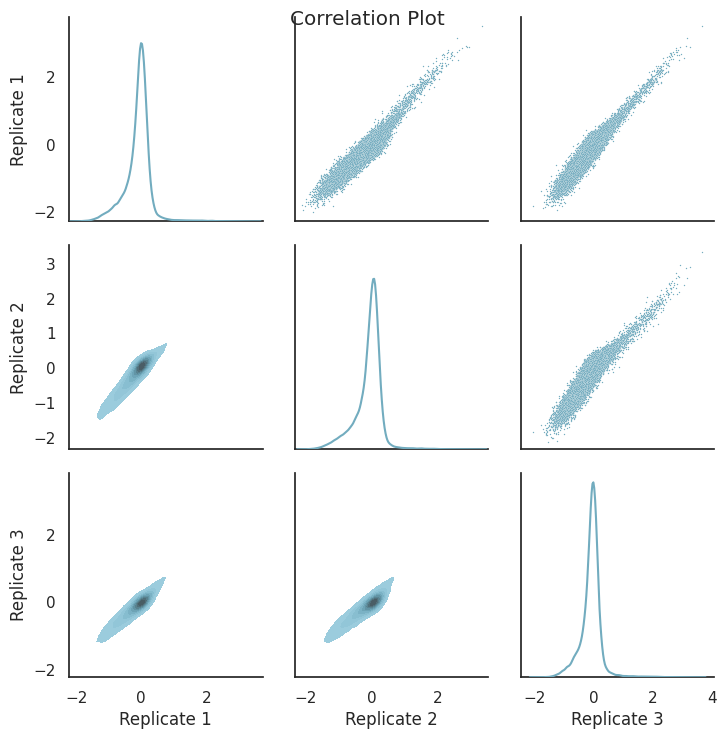

In [ ]:
mpra_oligo_data_NGN2.barcode_threshold = 50  # Only include oligos with ≥50 barcodes
correlation(mpra_oligo_data_NGN2, Modality.ACTIVITY)



#### Lower replicate correlation in WTC11 compared with NGN2

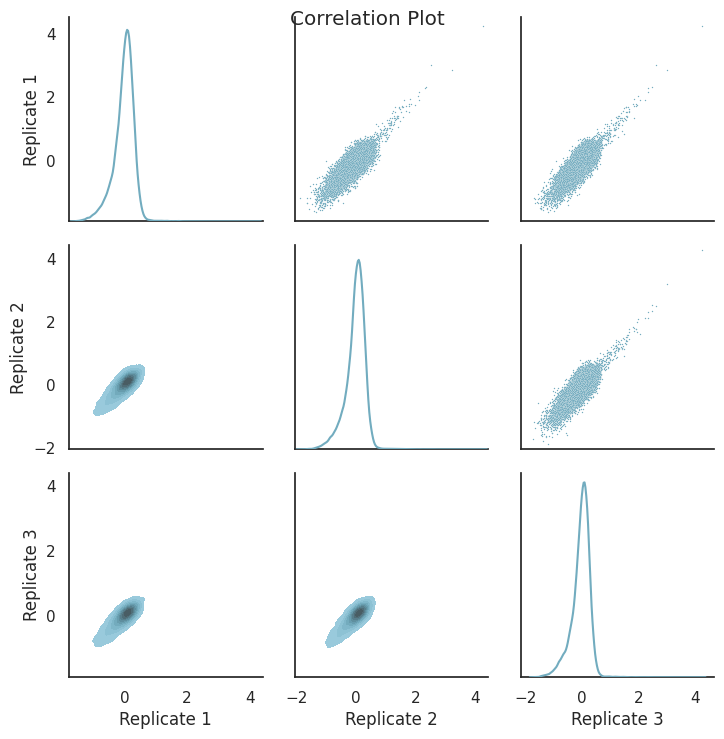

In [ ]:
mpra_oligo_data_WTC11.barcode_threshold = 50  # Only include oligos with ≥50 barcodes
correlation(mpra_oligo_data_WTC11, Modality.ACTIVITY)



### Normalized DNA vs RNA plot -> median across replicates

#### NGN2

/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/utils/plot.py:73: RuntimeWarning: divide by zero encountered in log10
  df = pd.DataFrame({"DNA [log10]": np.log10(median_dna), "RNA [log10]": np.log10(median_rna)})


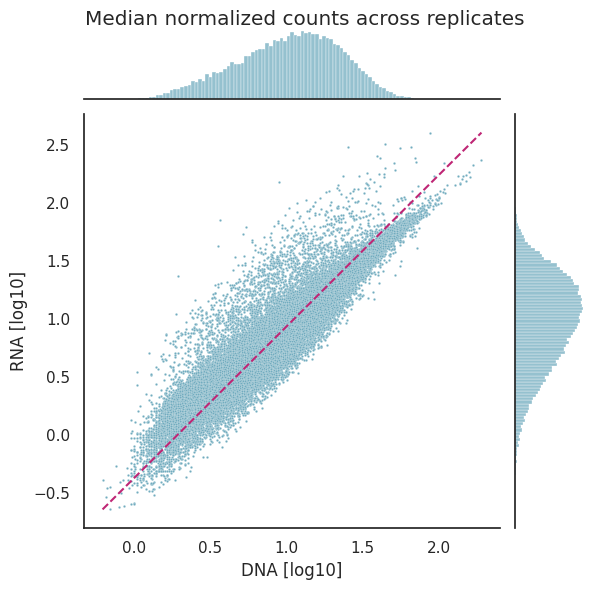

In [ ]:
# Set barcode threshold to include all oligos (threshold = 1)
mpra_oligo_data_NGN2.barcode_threshold = 10

# Plot normalized DNA vs normalized RNA (median across replicates)
dna_vs_rna(mpra_oligo_data_NGN2)

#### WTC11

/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/utils/plot.py:73: RuntimeWarning: divide by zero encountered in log10
  df = pd.DataFrame({"DNA [log10]": np.log10(median_dna), "RNA [log10]": np.log10(median_rna)})


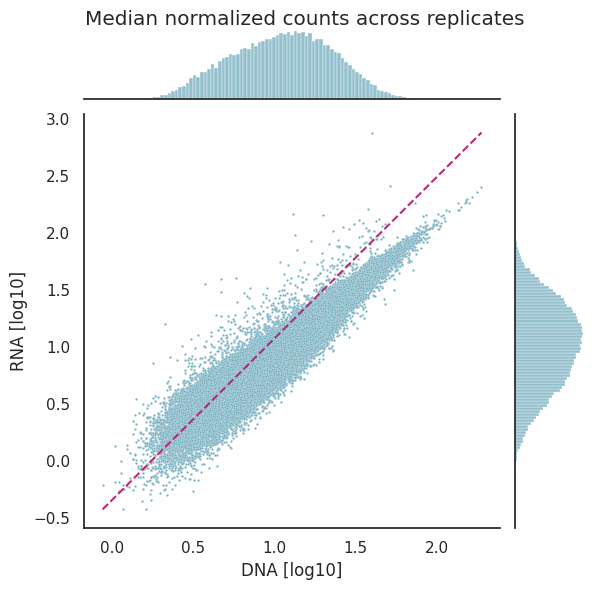

In [ ]:
# Set barcode threshold to include all oligos (threshold = 1)
mpra_oligo_data_WTC11.barcode_threshold = 10

# Plot normalized DNA vs normalized RNA (median across replicates)
dna_vs_rna(mpra_oligo_data_WTC11)

### Show distribution of barcodes per oligo -> red = median, blue = mean

#### NGN2

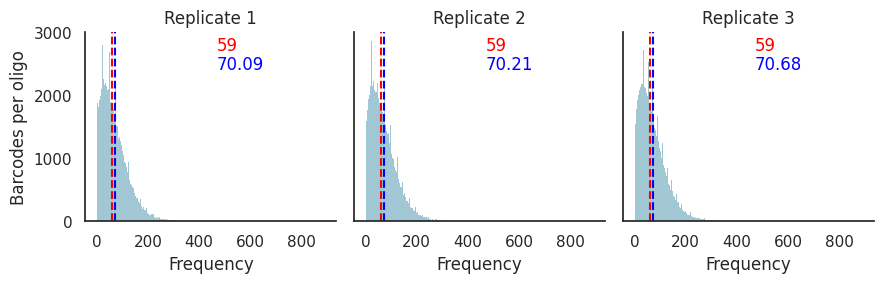

In [ ]:
barcodes_per_oligo(mpra_oligo_data_NGN2)

#### WTC11

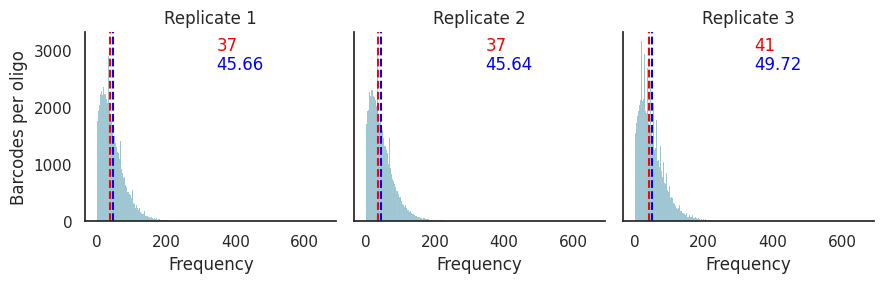

In [ ]:
barcodes_per_oligo(mpra_oligo_data_WTC11)

In [ ]:
# Set barcode threshold for oligo aggregation
NGN2_barcode_data.barcode_threshold = 10

# Reset barcode filter to include all barcodes
NGN2_barcode_data.var_filter = None

# Aggregate to oligo-level data
mpra_oligo_data = NGN2_barcode_data.oligo_data

# Show mean Pearson correlation and oligo counts before filtering
mean_corr_before = np.mean(mpra_oligo_data.correlation()[np.triu_indices_from(mpra_oligo_data.correlation(), k=1)])
oligos_before = np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold, axis=1)
print(f"Mean Pearson correlation before barcode filter (threshold={mpra_oligo_data.barcode_threshold}): {mean_corr_before:.2f}")
print(f"Number of oligos per replicate before filter: {oligos_before}")

# Apply oligo-specific outlier filter (z-score method)
NGN2_barcode_data.apply_barcode_filter(BarcodeFilter.OLIGO_SPECIFIC, {"times_zscore": 3})

# Re-aggregate to oligo-level after filtering
mpra_oligo_data = NGN2_barcode_data.oligo_data

# Show mean Pearson correlation and oligo counts after filtering
mean_corr_after = np.mean(mpra_oligo_data.correlation()[np.triu_indices_from(mpra_oligo_data.correlation(), k=1)])
oligos_after = np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold, axis=1)
print(f"Mean Pearson correlation after barcode filter (threshold={mpra_oligo_data.barcode_threshold}): {mean_corr_after:.2f}")
print(f"Number of oligos per replicate after filter: {oligos_after}")

/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/mpradata.py:276: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  ratio = np.divide(


Mean Pearson correlation before barcode filter (threshold=10): 0.89
Number of oligos per replicate before filter: [72732 72712 72740]


/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/mpradata.py:276: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  ratio = np.divide(


Mean Pearson correlation after barcode filter (threshold=10): 0.89
Number of oligos per replicate after filter: [72732 72712 72740]


#### WTC11

In [ ]:
# Set barcode threshold for oligo aggregation
WTC11_barcode_data.barcode_threshold = 10

# Reset barcode filter to include all barcodes
WTC11_barcode_data.var_filter = None

# Aggregate to oligo-level data
mpra_oligo_data = WTC11_barcode_data.oligo_data

# Show mean Pearson correlation and oligo counts before filtering
mean_corr_before = np.mean(mpra_oligo_data.correlation()[np.triu_indices_from(mpra_oligo_data.correlation(), k=1)])
oligos_before = np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold, axis=1)
print(f"Mean Pearson correlation before barcode filter (threshold={mpra_oligo_data.barcode_threshold}): {mean_corr_before:.2f}")
print(f"Number of oligos per replicate before filter: {oligos_before}")

# Apply oligo-specific outlier filter (z-score method)
WTC11_barcode_data.apply_barcode_filter(BarcodeFilter.OLIGO_SPECIFIC, {"times_zscore": 3})

# Re-aggregate to oligo-level after filtering
mpra_oligo_data = WTC11_barcode_data.oligo_data

# Show mean Pearson correlation and oligo counts after filtering
mean_corr_after = np.mean(mpra_oligo_data.correlation()[np.triu_indices_from(mpra_oligo_data.correlation(), k=1)])
oligos_after = np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold, axis=1)
print(f"Mean Pearson correlation after barcode filter (threshold={mpra_oligo_data.barcode_threshold}): {mean_corr_after:.2f}")
print(f"Number of oligos per replicate after filter: {oligos_after}")

/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/mpradata.py:276: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  ratio = np.divide(


Mean Pearson correlation before barcode filter (threshold=10): 0.75
Number of oligos per replicate before filter: [68960 69079 69921]


/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/mpradata.py:276: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  ratio = np.divide(


Mean Pearson correlation after barcode filter (threshold=10): 0.74
Number of oligos per replicate after filter: [68960 69079 69921]


### Find barcodes removed in all replicates
Removed barcodes are oligo-specific outliers that deviate strongly from the barcode distribution of the same oligo.  
|z| > 3

#### NGN2

In [ ]:
# Find barcodes removed in all replicates
common_barcodes = None
n_replicates = NGN2_barcode_data.var_filter.shape[1]

for i in range(n_replicates):
    # Get barcodes removed in replicate i
    removed = NGN2_barcode_data.data.var_names[NGN2_barcode_data.var_filter[:, i]]
    print(f"Number of removed barcodes in replicate {i + 1}: {len(removed)}")
    # Initialize or update the set of common removed barcodes
    if common_barcodes is None:
        common_barcodes = set(removed)
    else:
        common_barcodes &= set(removed)

print(f"\nNumber of common removed barcodes in all replicates: {len(common_barcodes)}")
print(f"Commonly removed barcodes: {list(common_barcodes)[:10]} ...")  # Show first 10 for brevity

Number of removed barcodes in replicate 1: 77735
Number of removed barcodes in replicate 2: 78304
Number of removed barcodes in replicate 3: 78690

Number of common removed barcodes in all replicates: 26807
Commonly removed barcodes: ['GGTCGGACGTTCCTA', 'GGGCTTTTCGCAGAC', 'AACGTGTTTACGCAG', 'GGCCTGAAAAGTACA', 'AAGTTGGCACGGATA', 'TAGGGCCCGCTCGTC', 'CGGTGAGGACCAATA', 'ACAGAAGGGTTACTC', 'GCCACCGGTACGTGG', 'TGAGAGACCTTACGT'] ...


#### WTC11

In [ ]:
# Find barcodes removed in all replicates
common_barcodes = None
n_replicates = WTC11_barcode_data.var_filter.shape[1]

for i in range(n_replicates):
    # Get barcodes removed in replicate i
    removed = WTC11_barcode_data.data.var_names[WTC11_barcode_data.var_filter[:, i]]
    print(f"Number of removed barcodes in replicate {i + 1}: {len(removed)}")
    # Initialize or update the set of common removed barcodes
    if common_barcodes is None:
        common_barcodes = set(removed)
    else:
        common_barcodes &= set(removed)

print(f"\nNumber of common removed barcodes in all replicates: {len(common_barcodes)}")
print(f"Commonly removed barcodes: {list(common_barcodes)[:10]} ...")  # Show first 10 for brevity

Number of removed barcodes in replicate 1: 45290
Number of removed barcodes in replicate 2: 45197
Number of removed barcodes in replicate 3: 50087

Number of common removed barcodes in all replicates: 9671
Commonly removed barcodes: ['GGCCGGACTCGGAAT', 'TGCACCTGGCCTTAG', 'TGGACTCGGGGGTGA', 'AACACGATTCATCTT', 'AATTACGGAAGGAGG', 'AACGTGTTTACGCAG', 'GGCCTGAAAAGTACA', 'TTTTTATCTGATCTA', 'AAGTTGGCACGGATA', 'CAACGCGTTTTCCGG'] ...


#### Mean pearson correlation after removing the barcode outliers

#### NGN2

In [ ]:
# Reset barcode filter to include all barcodes
NGN2_barcode_data.var_filter = None

# Aggregate to oligo-level data
mpra_oligo_data = NGN2_barcode_data.oligo_data

print(f"Mean Pearson correlation before barcode filter (barcode threshold={mpra_oligo_data.barcode_threshold}):")
mean_corr_before = np.mean(mpra_oligo_data.correlation()[np.triu_indices_from(mpra_oligo_data.correlation(), k=1)])
print(f"{mean_corr_before:.3f}")

print("Number of oligos per replicate (before filter):")
oligos_before = np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold, axis=1)
print(oligos_before)

# Apply barcode filter: require minimum DNA and RNA counts per barcode
NGN2_barcode_data.apply_barcode_filter(BarcodeFilter.MIN_COUNT, {"dna_min_count": 2, "rna_min_count": 4})

# Re-aggregate to oligo-level after filtering
mpra_oligo_data = NGN2_barcode_data.oligo_data

print(f"\nMean Pearson correlation after barcode filter (barcode threshold={mpra_oligo_data.barcode_threshold}):")
mean_corr_after = np.mean(mpra_oligo_data.correlation()[np.triu_indices_from(mpra_oligo_data.correlation(), k=1)])
print(f"{mean_corr_after:.3f}")

print("Number of oligos per replicate (after filter):")
oligos_after = np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold, axis=1)
print(oligos_after)

Mean Pearson correlation before barcode filter (barcode threshold=10):


/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/mpradata.py:276: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  ratio = np.divide(


0.894
Number of oligos per replicate (before filter):
[72732 72712 72740]

Mean Pearson correlation after barcode filter (barcode threshold=10):


/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/mpradata.py:276: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  ratio = np.divide(


0.857
Number of oligos per replicate (after filter):
[67959 67733 67734]


#### WTC11

In [ ]:
# Reset barcode filter to include all barcodes
WTC11_barcode_data.var_filter = None

# Aggregate to oligo-level data
mpra_oligo_data = WTC11_barcode_data.oligo_data

print(f"Mean Pearson correlation before barcode filter (barcode threshold={mpra_oligo_data.barcode_threshold}):")
mean_corr_before = np.mean(mpra_oligo_data.correlation()[np.triu_indices_from(mpra_oligo_data.correlation(), k=1)])
print(f"{mean_corr_before:.3f}")

print("Number of oligos per replicate (before filter):")
oligos_before = np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold, axis=1)
print(oligos_before)

# Apply barcode filter: require minimum DNA and RNA counts per barcode
WTC11_barcode_data.apply_barcode_filter(BarcodeFilter.MIN_COUNT, {"dna_min_count": 2, "rna_min_count": 4})

# Re-aggregate to oligo-level after filtering
mpra_oligo_data = WTC11_barcode_data.oligo_data

print(f"\nMean Pearson correlation after barcode filter (barcode threshold={mpra_oligo_data.barcode_threshold}):")
mean_corr_after = np.mean(mpra_oligo_data.correlation()[np.triu_indices_from(mpra_oligo_data.correlation(), k=1)])
print(f"{mean_corr_after:.3f}")

print("Number of oligos per replicate (after filter):")
oligos_after = np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold, axis=1)
print(oligos_after)

Mean Pearson correlation before barcode filter (barcode threshold=10):


/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/mpradata.py:276: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  ratio = np.divide(


0.745
Number of oligos per replicate (before filter):
[68960 69079 69921]

Mean Pearson correlation after barcode filter (barcode threshold=10):


/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/mpralib/mpradata.py:276: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  ratio = np.divide(


0.675
Number of oligos per replicate (after filter):
[66398 66876 67687]


In [ ]:
#NGN2_barcode_data.barcode_threshold = 0
NGN2_barcode_data
export_barcode_file(NGN2_barcode_data, 'data/mpralib/NGN2_mpra_lib_bc_1.tsv.gz')

In [ ]:
NGN2_bc_1 = pd.read_table('data/mpralib/NGN2_mpra_lib_bc_1.tsv.gz')

In [ ]:
NGN2_barcode.equals(df_NGN2)

True

# Load oligo and barcode files from MPRAlib and the experiment file from MPRAsnakeflow

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from mpralib.mpradata import MPRABarcodeData
from mpralib.mpradata import Modality
from mpralib.utils.plot import dna_vs_rna, barcodes_per_oligo
from mpralib.utils.plot import correlation
from mpralib.mpradata import BarcodeFilter
from mpralib.utils.io import export_activity_file
from mpralib.utils.io import export_barcode_file
from scipy.stats import spearmanr, pearsonr

In [2]:
NGN2_barcode_data = MPRABarcodeData.from_file('data/reporter_experiment.barcode.NGN2.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')
WTC11_barcode_data = MPRABarcodeData.from_file('data/reporter_experiment.barcode.WTC11.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')

In [3]:
df_NGN2 = pd.read_table('data/reporter_experiment.barcode.NGN2.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')
df_WTC11 = pd.read_table('data/reporter_experiment.barcode.WTC11.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')

### Save barcode and oligo files to a tsv file

In [4]:
#export_activity_file(NGN2_barcode_data.oligo_data, 'data/mpralib/NGN2_mpralib_oligo.tsv.gz')
#export_barcode_file(NGN2_barcode_data, 'data/mpralib/NGN2_mpra_lib_barcode.tsv.gz')
#export_activity_file(WTC11_barcode_data.oligo_data, 'data/mpralib/WTC11_mpralib_oligo.tsv.gz')
#export_barcode_file(WTC11_barcode_data, 'data/mpralib/WTC11_mpra_lib_barcode.tsv.gz')

In [5]:
#NGN2_oligo = pd.read_table('data/mpralib/NGN2_mpralib_oligo.tsv.gz')
#NGN2_barcode = pd.read_table('data/mpralib/NGN2_mpra_lib_barcode.tsv.gz')
#WTC11_oligo = pd.read_table('data/mpralib/WTC11_mpralib_oligo.tsv.gz')
#WTC11_barcode = pd.read_table('data/mpralib/WTC11_mpra_lib_barcode.tsv.gz')

### Get DNA normalisation per barcode and replication

In [6]:
NGN2_dna_norm = pd.DataFrame(data = NGN2_barcode_data.normalized_dna_counts,
                             index = NGN2_barcode_data.data.obs_names,
                             columns = NGN2_barcode_data.data.var_names
                             )
NGN2_dna_norm = NGN2_dna_norm.T
NGN2_dna_norm.columns = ['DNA_norm_1', 'DNA_norm_2', 'DNA_norm_3']

WTC11_dna_norm = pd.DataFrame(data = WTC11_barcode_data.normalized_dna_counts,
                             index = WTC11_barcode_data.data.obs_names,
                             columns = WTC11_barcode_data.data.var_names
                             )
WTC11_dna_norm = WTC11_dna_norm.T
WTC11_dna_norm.columns = ['DNA_norm_1', 'DNA_norm_2', 'DNA_norm_3']

In [7]:
NGN2_rna_norm = pd.DataFrame(data = NGN2_barcode_data.normalized_rna_counts,
                             index = NGN2_barcode_data.data.obs_names,
                             columns = NGN2_barcode_data.data.var_names
                             )
NGN2_rna_norm = NGN2_rna_norm.T
NGN2_rna_norm.columns = ['RNA_norm_1', 'RNA_norm_2', 'RNA_norm_3']

WTC11_rna_norm = pd.DataFrame(data = WTC11_barcode_data.normalized_rna_counts,
                             index = WTC11_barcode_data.data.obs_names,
                             columns = WTC11_barcode_data.data.var_names
                             )
WTC11_rna_norm = WTC11_rna_norm.T
WTC11_rna_norm.columns = ['RNA_norm_1', 'RNA_norm_2', 'RNA_norm_3']

#### Join the normalized DNA and RNA counts

In [8]:
NGN2_norm = NGN2_dna_norm.join(NGN2_rna_norm)
WTC11_norm = WTC11_dna_norm.join(WTC11_rna_norm)

### Mapping oligoname to Barcode

In [9]:
NGN2_barcode_to_oligo = df_NGN2.set_index('barcode')['oligo_name']
NGN2_norm['oligo_name'] = NGN2_norm.index.map(NGN2_barcode_to_oligo)
NGN2_norm.insert(
    0,
    'oligo_name',
    NGN2_norm.pop('oligo_name')
)

In [12]:
NGN2_norm

,oligo_name,DNA_norm_1,DNA_norm_2,DNA_norm_3,RNA_norm_1,RNA_norm_2,RNA_norm_3
barcode,,,,,,,
ACGAGGGGTTTGCTC,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0.000000,0.114577,0.075492,0.000000,0.047915,0.061881
CAGATCGGTTGATTC,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0.235082,0.267347,0.113238,0.164364,0.095830,0.185643
CTGTTGGTCTATACG,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0.078361,0.114577,0.075492,0.134479,0.063886,0.092821
GATTCGAATGTGTGG,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0.235082,0.267347,0.339713,0.224132,0.239574,0.262994
ACTTAGTTGTCTCTT,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0.117541,0.114577,0.075492,0.044826,0.031943,0.046411
...,...,...,...,...,...,...,...
TTGGTAAGAGGCTCC,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,0.078361,0.000000,0.113238,0.074711,0.000000,0.046411
GCCTAAGGAACCGAT,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,0.078361,0.114577,0.188729,0.104595,0.095830,0.061881
GGTACGCATTCGCTG,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,0.117541,0.076385,0.000000,0.104595,0.063886,0.000000


In [10]:
WTC11_barcode_to_oligo = df_WTC11.set_index('barcode')['oligo_name']
WTC11_norm['oligo_name'] = WTC11_norm.index.map(WTC11_barcode_to_oligo)
WTC11_norm.insert(
    0,
    'oligo_name',
    WTC11_norm.pop('oligo_name')
)

### Generating effect size for all barcode oligo combination per replicate

In [13]:
NGN2_norm['effect_size_1'] = np.log2(NGN2_norm['RNA_norm_1']/NGN2_norm['DNA_norm_1'])
NGN2_norm['effect_size_2'] = np.log2(NGN2_norm['RNA_norm_2']/NGN2_norm['DNA_norm_2'])
NGN2_norm['effect_size_3'] = np.log2(NGN2_norm['RNA_norm_3']/NGN2_norm['DNA_norm_3'])

In [14]:
WTC11_norm['effect_size_1'] = np.log2(WTC11_norm['RNA_norm_1']/WTC11_norm['DNA_norm_1'])
WTC11_norm['effect_size_2'] = np.log2(WTC11_norm['RNA_norm_2']/WTC11_norm['DNA_norm_2'])
WTC11_norm['effect_size_3'] = np.log2(WTC11_norm['RNA_norm_3']/WTC11_norm['DNA_norm_3'])

### Aggregate the effect sizes into a mean and varianz per oligo

In [15]:
NGN2_oligo_agg = NGN2_norm.groupby('oligo_name').agg(
    effect_size_mean_1 = ('effect_size_1', 'mean'),
    effect_size_var_1 = ('effect_size_1', 'var'),
    effect_size_mean_2 = ('effect_size_2', 'mean'),
    effect_size_var_2 = ('effect_size_2', 'var'),
    effect_size_mean_3 = ('effect_size_3', 'mean'),
    effect_size_var_3 = ('effect_size_3', 'var')
    
).reset_index()

In [16]:
NGN2_oligo_agg

,oligo_name,effect_size_mean_1,effect_size_var_1,effect_size_mean_2,effect_size_var_2,effect_size_mean_3,effect_size_var_3
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,-0.172726,0.672653,-0.024072,0.705486,-0.074622,0.551786
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0.924314,0.533602,0.572807,0.732841,0.792823,0.558615
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,-0.081799,0.537929,0.164141,0.621226,-0.114922,0.678007
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,0.104166,0.626642,-0.053371,0.751469,-0.116782,0.427317
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,0.054007,0.450122,0.043255,0.609228,0.014599,0.626581
...,...,...,...,...,...,...,...
77940,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,-0.943446,0.968977,-1.035842,0.763667,-1.365880,0.502598
77941,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,0.734612,0.805421,0.515278,0.553243,0.790766,0.969502
77942,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,0.277300,0.838213,0.482528,0.517162,0.136078,0.678196
77943,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,-0.886199,0.400889,-0.657633,0.649180,-0.694418,0.524540


In [17]:
WTC11_oligo_agg = WTC11_norm.groupby('oligo_name').agg(
    effect_size_mean_1 = ('effect_size_1', 'mean'),
    effect_size_var_1 = ('effect_size_1', 'var'),
    effect_size_mean_2 = ('effect_size_2', 'mean'),
    effect_size_var_2 = ('effect_size_2', 'var'),
    effect_size_mean_3 = ('effect_size_3', 'mean'),
    effect_size_var_3 = ('effect_size_3', 'var')
    
).reset_index()

In [18]:
NGN2_long = NGN2_norm.melt(
    id_vars = ['oligo_name'],
    value_vars = ['effect_size_1', 'effect_size_2', 'effect_size_3'],
    var_name = 'replicate',
    value_name = 'effect_size'
)
NGN2_oligo_agg2 = (
    NGN2_long
    .groupby('oligo_name')['effect_size']
    .agg(['mean', 'var', 'count'])
    .reset_index()
)

In [16]:
NGN2_long

,oligo_name,replicate,effect_size
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,effect_size_1,NaN
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,effect_size_1,-0.516275
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,effect_size_1,0.779181
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,effect_size_1,-0.068816
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,effect_size_1,-1.390744
...,...,...,...
19159018,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,effect_size_3,-1.286826
19159019,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,effect_size_3,-1.608754
19159020,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,effect_size_3,NaN
19159021,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,effect_size_3,-1.871788


In [25]:
NGN2_oligo_agg2["var"].describe()

count    77891.000000
mean         0.654604
std          0.127010
min          0.000010
25%          0.595833
50%          0.651586
75%          0.709776
max          5.968141
Name: var, dtype: float64

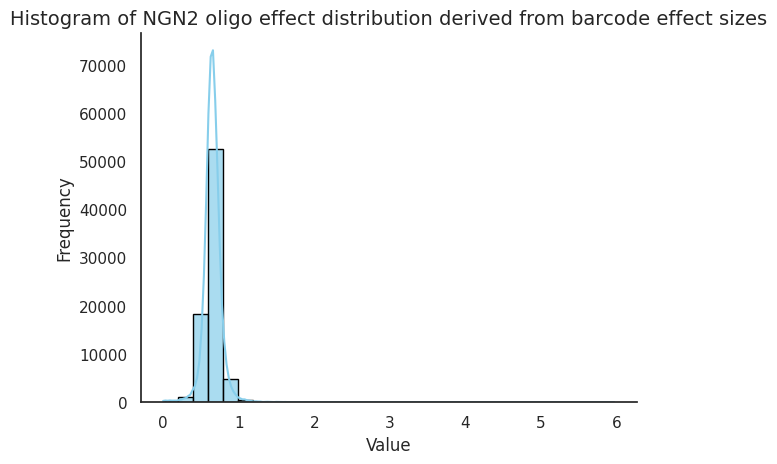

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create the plot
sns.histplot(NGN2_oligo_agg2["var"], kde=True, bins=30, color="skyblue", edgecolor="black", alpha=0.7)

# Add titles and labels
plt.title("Histogram of NGN2 oligo effect distribution derived from barcode effect sizes", fontsize=14)
plt.xlabel("Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Show the plot
plt.show()

In [22]:
NGN2_oligo_agg2

,oligo_name,mean,var,count
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,-0.090279,0.641487,392
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0.761915,0.626512,345
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,-0.011880,0.624914,269
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,-0.023516,0.606437,332
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,0.036960,0.557586,190
...,...,...,...,...
77940,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,-1.099626,0.775738,77
77941,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,0.681147,0.785789,295
77942,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,0.297332,0.680394,92
77943,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,-0.746083,0.526175,120


In [28]:
WTC11_long = WTC11_norm.melt(
    id_vars = ['oligo_name'],
    value_vars = ['effect_size_1', 'effect_size_2', 'effect_size_3'],
    var_name = 'replicate',
    value_name = 'effect_size'
)
WTC11_oligo_agg2 = (
    WTC11_long
    .groupby('oligo_name')['effect_size']
    .agg(['mean', 'var', 'count'])
    .reset_index()
)

In [29]:
NGN2_oligo_mean_var = NGN2_oligo_agg.merge(
    right = NGN2_oligo_agg2,
    how = 'outer',
    on = 'oligo_name'
)

In [30]:
WTC11_oligo_mean_var = WTC11_oligo_agg.merge(
    right = WTC11_oligo_agg2,
    how = 'outer',
    on = 'oligo_name'
)

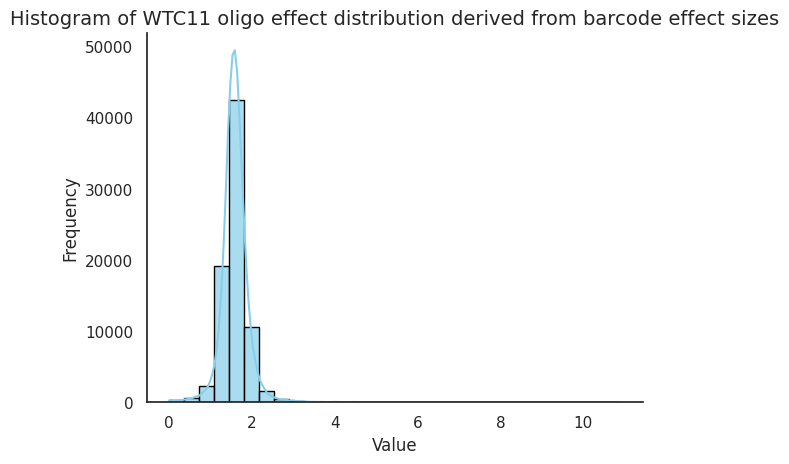

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create the plot
sns.histplot(WTC11_oligo_agg2["var"], kde=True, bins=30, color="skyblue", edgecolor="black", alpha=0.7)

# Add titles and labels
plt.title("Histogram of WTC11 oligo effect distribution derived from barcode effect sizes", fontsize=14)
plt.xlabel("Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Show the plot
plt.show()

### Merge the aggregated values from NGN2 and WTC11

In [33]:
oligo_mean_var = NGN2_oligo_mean_var.merge(right = WTC11_oligo_mean_var,
                                           how = 'outer',
                                           on = 'oligo_name',
                                           suffixes = ['_NGN2', '_WTC11'])

### Load the combined table from the MPRAsnakflow with the Bcalm data

In [34]:
element_merge = pd.read_table('data/results/merge_elements/element_merge.tsv.gz')

### Merge the tables

In [35]:
element_merge_v2 = element_merge.merge(
    right = oligo_mean_var,
    how = 'outer',
    on = 'oligo_name'
)

### Sort the table for NGN2 and WTC11

In [36]:
base_cols = element_merge_v2[element_merge_v2.columns[~element_merge_v2.columns.str.endswith(('_NGN2', '_WTC11'))]]
NGN2_cols = pd.DataFrame()
WTC11_cols = pd.DataFrame()

for i in element_merge_v2.columns:
    if i.endswith('_NGN2'):
        NGN2_cols[i] = element_merge_v2[i]

for i in element_merge_v2.columns:
    if i.endswith('_WTC11'):
        WTC11_cols[i] = element_merge_v2[i]


In [37]:
element_merge_v3 = pd.concat(
    [base_cols, NGN2_cols, WTC11_cols],
    axis=1
)

### Save element_merge_v3

In [38]:
element_merge_v3.to_csv('data/results/merge_elements/element_merge_v3.tsv.gz',
                        sep = '\t',
                        index = False)

In [39]:
element_merge_v3

,oligo_name,label,dna_count_1_NGN2,dna_count_2_NGN2,dna_count_3_NGN2,rna_count_1_NGN2,rna_count_2_NGN2,rna_count_3_NGN2,unique_barcode_count_NGN2,effect_size_NGN2,...,adj.P.Value_WTC11,effect_size_mean_1_WTC11,effect_size_var_1_WTC11,effect_size_mean_2_WTC11,effect_size_var_2_WTC11,effect_size_mean_3_WTC11,effect_size_var_3_WTC11,mean_WTC11,var_WTC11,count_WTC11
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,C_SLEA,537.0,509.0,538.0,1536.0,1465.0,1567.0,151.0,0.009842,...,1.0,-0.026272,1.775796,-0.039558,1.560437,0.142006,1.529057,0.028195,1.612354,277.0
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,C_SLEA,478.0,559.0,597.0,3122.0,2489.0,3020.0,131.0,0.891777,...,1.0,0.285834,1.798478,0.282512,1.738816,0.480271,1.218702,0.350755,1.577766,262.0
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,C_SLEA,334.0,294.0,336.0,1009.0,1005.0,966.0,99.0,0.092969,...,1.0,0.014818,1.622480,-0.050550,1.531677,-0.272072,1.612328,-0.106597,1.585365,173.0
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,C_SLEA,400.0,467.0,497.0,1356.0,1328.0,1301.0,121.0,0.024602,...,1.0,0.002025,1.726153,-0.019143,1.557797,0.015188,1.764868,-0.000271,1.671825,255.0
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,C_SLEA,261.0,269.0,300.0,841.0,816.0,855.0,68.0,0.092226,...,1.0,0.410487,1.797407,-0.025246,1.129114,0.015887,1.241663,0.132340,1.407154,138.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77954,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-1.096076,2.241562,-0.918203,4.874285,-1.941843,0.687798,-1.266213,2.874498,39.0
77955,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,cardiac_neuro_cava_random,300.0,334.0,315.0,1890.0,1504.0,1839.0,115.0,0.969816,...,1.0,-0.106458,1.994591,-0.386325,2.190748,-0.142450,1.249340,-0.218239,1.800376,189.0
77956,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,cardiac_neuro_cava_random,97.0,79.0,112.0,389.0,358.0,390.0,38.0,0.617933,...,1.0,-0.179720,2.354860,-0.228767,0.888492,-0.073833,1.525254,-0.155595,1.493632,65.0
77957,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.618327,2.929338,-0.729206,1.536935,-0.727574,0.973886,-0.697145,1.678265,74.0


### Plot of the variance of the oligos from NGN2 and WTC11

In [40]:
element_merge_v3_long_var = element_merge_v3.melt(value_vars= ['var_NGN2', 'var_WTC11'],
                                              var_name = 'cell_type',
                                              value_name = 'variance')
element_merge_v3_long_var['cell_type'] = element_merge_v3_long_var['cell_type'].replace({
    'var_NGN2': 'NGN2',
    'var_WTC11': 'WTC11'
})
element_merge_v3_long_var['log_variance'] = np.log1p(
    element_merge_v3_long_var['variance']
)
element_merge_v3_long_mean = element_merge_v3.melt(value_vars= ['mean_NGN2', 'mean_WTC11'],
                                              var_name = 'cell_type',
                                              value_name = 'mean')
element_merge_v3_long_mean['cell_type'] = element_merge_v3_long_var['cell_type'].replace({
    'mean_NGN2': 'NGN2',
    'mean_WTC11': 'WTC11'
})

In [41]:
element_merge_v3_long_var

,cell_type,variance,log_variance
0,NGN2,0.641487,0.495602
1,NGN2,0.626512,0.486438
2,NGN2,0.624914,0.485455
3,NGN2,0.606437,0.474019
4,NGN2,0.557586,0.443137
...,...,...,...
155913,WTC11,2.874498,1.354416
155914,WTC11,1.800376,1.029754
155915,WTC11,1.493632,0.913740
155916,WTC11,1.678265,0.985169


/tmp/ipykernel_3775/3323114936.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3775/3323114936.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


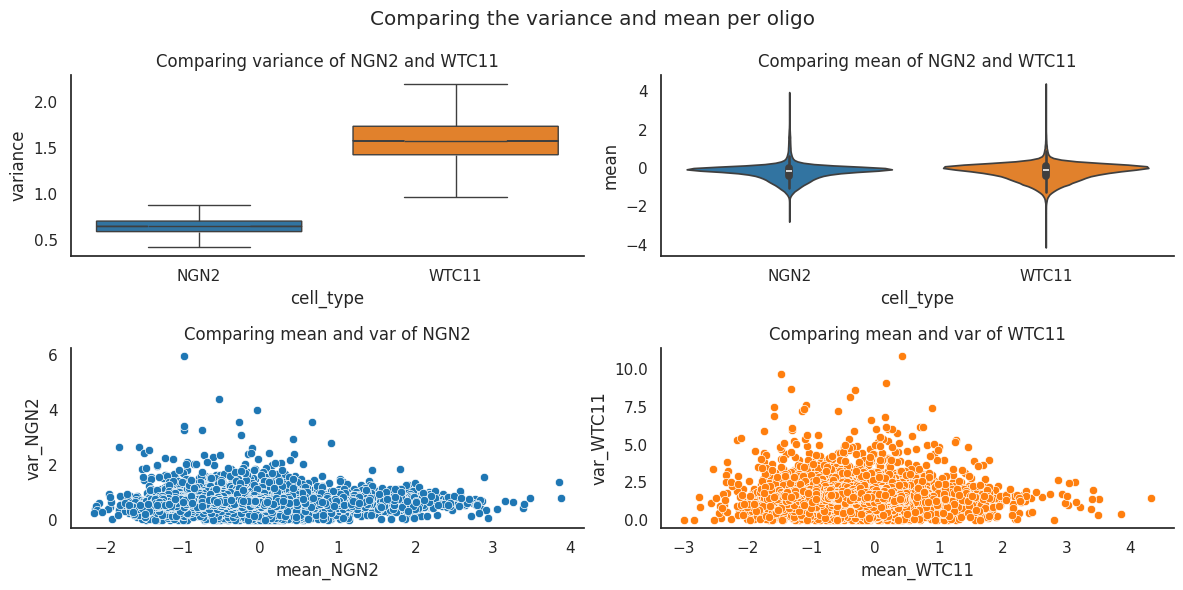

In [48]:
fig, axes = plt.subplots(2,2, figsize = (12,6))
cell_colors = {
    'NGN2': 'tab:blue',
    'WTC11': 'tab:orange'
}
# sns.violinplot(
#     data = element_merge_v3_long_var,
#     x = 'cell_type',
#     y = 'variance',
#     palette = cell_colors,
#     ax = axes[0][0]
# )
sns.boxplot(
    data = element_merge_v3_long_var,
    x = 'cell_type',
    y = 'variance',
    palette = cell_colors,
    ax = axes[0][0],
    showfliers=False,
    notch=True
)
axes[0][0].set_title('Comparing variance of NGN2 and WTC11')

sns.violinplot(
    data = element_merge_v3_long_mean,
    x = 'cell_type',
    y = 'mean',
    palette = cell_colors,
    ax = axes[0][1]
)
# sns.boxplot(
#     data = element_merge_v3_long_mean,
#     x = 'cell_type',
#     y = 'mean',
#     palette = cell_colors,
#     ax = axes[0][1],
#     showfliers=False,
#     notch=True
# )
axes[0][1].set_title('Comparing mean of NGN2 and WTC11')

sns.scatterplot(
    data = element_merge_v3,
    x = 'mean_NGN2',
    y = 'var_NGN2',
    color = cell_colors['NGN2'],
    ax = axes[1][0]
)
axes[1][0].set_title('Comparing mean and var of NGN2')

sns.scatterplot(
    data = element_merge_v3,
    x = 'mean_WTC11',
    y = 'var_WTC11',
    color = cell_colors['WTC11'],
    ax = axes[1][1]
)
axes[1][1].set_title('Comparing mean and var of WTC11')


plt.suptitle('Comparing the variance and mean per oligo')
plt.tight_layout()
plt.show()

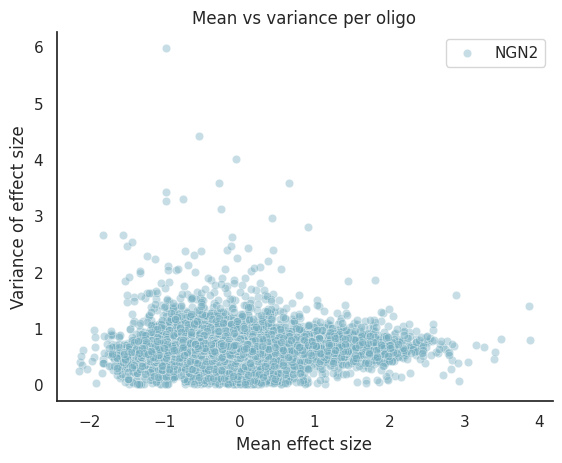

In [43]:
sns.scatterplot(
    data=element_merge_v3,
    x='mean_NGN2',
    y='var_NGN2',
    label='NGN2',
    alpha=0.4
)



plt.xlabel('Mean effect size')
plt.ylabel('Variance of effect size')
plt.title('Mean vs variance per oligo')
plt.legend()



<Axes: xlabel='mean_NGN2', ylabel='var_NGN2'>

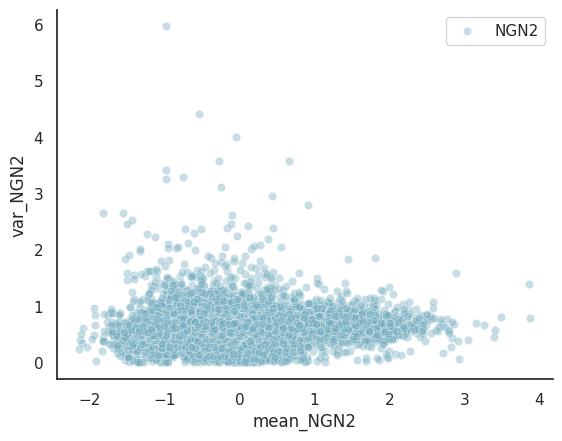

In [44]:
sns.scatterplot(
    data=element_merge_v3,
    x='mean_NGN2',
    y='var_NGN2',
    label='NGN2',
    alpha=0.4
)